# Mochatrade Risk — ML Layer for Leverage & Margin Risk
### Team DotLocal · `MochaGaurd-Team-DotLocal`

This notebook trains a set of ML models that plug into the **Mochatrade Risk** engine
(leveraged US-stock trading risk service) on top of **real historical market data** pulled
live from Yahoo Finance (`yfinance`) — no Kaggle CSVs, no synthetic data in the final run.

**What gets built here (4 models, one shared "leverage formulation" function):**

| # | Model | Type | Feeds |
|---|-------|------|-------|
| 1 | Forward volatility forecaster | Regression (LightGBM) | Recommended max leverage |
| 2 | Margin-breach / leverage-risk classifier | Calibrated classification | `P(breach \| leverage, market state)` |
| 3 | Overnight gap-risk forecaster | Regression (LightGBM) | Overnight margin sizing |
| 4 | Regime / anomaly detector | Unsupervised (Isolation Forest) | Unusual-risk-day flags |

**Design note — this respects your repo's own philosophy.** The README states the app
"deliberately has no demo fallback" and never renders invented values when real data is
unavailable. This notebook is built the same way: every model is trained on real,
timestamped OHLCV history, evaluated with a genuine walk-forward split (no shuffling, no
leakage), and the final inference wrapper (Section 9) is written so that a missing input
feature returns `None` with a flag rather than a fabricated number. Treat every model here
as a **supplementary risk signal** that sits next to your existing deterministic
leverage/overnight-margin calculation — not a replacement for it.

**Honest caveat on labels:** there is no public dataset of Mochatrade's actual historical
margin calls, so the breach-classifier labels are *derived from real price data* using a
configurable maintenance-margin threshold (Section 3) — not observed real breaches. Before
using it for real risk decisions, recalibrate that threshold against your actual margin
schedule and, once you have them, real historical breach/liquidation events.

**Storage:** every model file, metric, and diagnostic plot produced below is written to a
local `/content/artifacts` folder as it's created, and Section 11 mounts your Google Drive
and copies that whole folder into `MyDrive/MochaGuard/risk_ml_runs/` — both a timestamped,
permanent snapshot of this run and a `latest/` folder you can point your `api/` service at.
You'll get one Google auth prompt when Section 11 runs; approve it to grant Colab access to
your Drive.

Runtime: Google Colab, CPU is fine. Takes ~3–6 minutes end to end depending on how many
tickers/years you pull.


In [1]:
# ============================================================
# 0. SETUP
# ============================================================
!pip install -q yfinance lightgbm xgboost --upgrade

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import lightgbm as lgb
import joblib
import json
import shutil
import os
from datetime import datetime

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              roc_auc_score, average_precision_score, brier_score_loss,
                              confusion_matrix, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import IsolationForest

np.random.seed(42)

# Everything below accumulates here as it's created, then Section 11 copies the
# whole tree to Google Drive. Keeping one folder (rather than scattering files
# under /content) makes that final copy a single, reliable operation.
ARTIFACT_DIR = "/content/artifacts"
MODELS_DIR = f"{ARTIFACT_DIR}/models"
PLOTS_DIR = f"{ARTIFACT_DIR}/plots"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
results = {}  # every metric produced below gets recorded here, saved as results.json

print("Setup complete. Artifacts will accumulate in", ARTIFACT_DIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 42.5 MB/s eta 0:00:00
Setup complete. Artifacts will accumulate in /content/artifacts


## 1. Data Ingestion — real market data

We pull real, split/dividend-adjusted daily OHLCV history from Yahoo Finance for a
universe that mirrors the kind of book a leveraged US-stock product like Mochatrade would
actually carry: broad-market ETFs, mega-caps, and a few structurally high-volatility names
(so the models see both calm and violent regimes). We also pull **`^VIX`** — the real
market-wide implied-volatility index — as a market-state feature.

Swap `TICKERS` for your own real universe (or read it from `api/` config) at any time —
nothing below is ticker-specific.


In [2]:
# ============================================================
# 1. DATA INGESTION (real Yahoo Finance data)
# ============================================================
TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META",
           "TSLA", "AMD", "JPM", "XOM", "COIN", "SMCI"]
MARKET_TICKER = "SPY"
START = "2015-01-01"
END = datetime.today().strftime("%Y-%m-%d")

print(f"Downloading {len(TICKERS)} tickers from {START} to {END} ...")
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True,
                   group_by="ticker", progress=False)

# yfinance with group_by='ticker' returns columns as (Ticker, Field).
# Swap to (Field, Ticker) so downstream code can do raw["Close"][ticker].
raw = raw.swaplevel(0, 1, axis=1).sort_index(axis=1)

vix = yf.download("^VIX", start=START, end=END, auto_adjust=True, progress=False)["Close"]
vix = vix.reindex(raw.index).ffill()
vix.name = "vix_level"

print("Raw panel shape:", raw.shape)
print("Date range:", raw.index.min().date(), "->", raw.index.max().date())
raw["Close"][TICKERS[:4]].tail()


Raw panel shape: (2940, 70)
Date range: 2015-01-02 -> 2026-09-11


Ticker,SPY,QQQ,AAPL,MSFT
Date,,,,
2026-09-04,770.190002,718.960022,319.970001,499.700012
2026-09-08,765.960022,718.359985,316.220001,493.950012
2026-09-09,762.400024,716.309998,315.339996,491.649994
2026-09-10,757.830017,708.690002,326.570007,492.440002
2026-09-11,764.289978,714.880005,332.269989,495.630005


## 2. Feature Engineering

Per symbol, per day, we compute the features an actual risk desk would look at: multi-
horizon realized volatility, ATR, overnight gap size, intraday range, a liquidity z-score,
RSI, rolling beta to the market, drawdown, day-of-week, plus the real VIX level as a
market-wide risk-regime signal.


In [3]:
# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================
def rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs_ = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs_))

def build_features(raw, tickers, market_ticker, vix_series):
    market_close = raw["Close"][market_ticker]
    market_ret = np.log(market_close / market_close.shift(1))
    rows = []
    for t in tickers:
        o, h, l, c, v = (raw["Open"][t], raw["High"][t], raw["Low"][t],
                          raw["Close"][t], raw["Volume"][t])
        df = pd.DataFrame(index=raw.index)
        df["symbol"] = t
        df["close"] = c
        log_ret = np.log(c / c.shift(1))
        df["log_ret"] = log_ret
        df["overnight_gap"] = np.log(o / c.shift(1))
        df["intraday_range"] = (h - l) / c
        prev_close = c.shift(1)
        tr = pd.concat([(h - l), (h - prev_close).abs(), (l - prev_close).abs()], axis=1).max(axis=1)
        df["atr_14"] = tr.rolling(14).mean() / c
        for w in (10, 20, 60):
            df[f"realized_vol_{w}d"] = log_ret.rolling(w).std() * np.sqrt(252)
        df["volume_z_20"] = (v - v.rolling(20).mean()) / v.rolling(20).std()
        df["dollar_volume"] = c * v
        df["rsi_14"] = rsi(c, 14)
        df["drawdown_20d"] = c / c.rolling(20).max() - 1
        cov = log_ret.rolling(60).cov(market_ret)
        var = market_ret.rolling(60).var()
        df["beta_60d"] = cov / var.replace(0, np.nan)
        df["dow"] = df.index.dayofweek
        df["vix_level"] = vix_series
        df["vix_chg_5d"] = vix_series.pct_change(5)

        # ---- prediction targets (see Section 3) ----
        df["target_next_abs_gap"] = df["overnight_gap"].shift(-1).abs()
        df["target_next_vol_10d"] = df["realized_vol_10d"].shift(-10)
        df["next_ret"] = log_ret.shift(-1)
        rows.append(df)
    out = pd.concat(rows)
    return out.dropna(subset=["realized_vol_10d"])

FEATURE_COLS = ["overnight_gap", "intraday_range", "atr_14",
                "realized_vol_10d", "realized_vol_20d", "realized_vol_60d",
                "volume_z_20", "rsi_14", "drawdown_20d", "beta_60d",
                "dow", "vix_level", "vix_chg_5d"]

feat = build_features(raw, TICKERS, MARKET_TICKER, vix)
print("Feature frame shape:", feat.shape)
feat[["symbol", "realized_vol_10d", "vix_level", "overnight_gap"]].tail()


Feature frame shape: (39440, 20)


,symbol,realized_vol_10d,vix_level,overnight_gap
Date,,,,
2026-09-04,SMCI,0.683033,14.530000,0.007629
2026-09-08,SMCI,0.584952,15.720000,0.002019
2026-09-09,SMCI,0.447880,16.459999,-0.006229
2026-09-10,SMCI,0.474277,17.840000,-0.026550
2026-09-11,SMCI,0.579577,15.840000,0.010114


## 3. Label Construction — mapping to leverage estimation / detection / formulation

Three real-price-derived targets, each mapped to a concrete risk-engine use case:

- **`target_next_vol_10d`** — next 10-day realized volatility → drives *leverage
  formulation* (Section 6): lower predicted vol → higher safe leverage, and vice versa.
- **`target_next_abs_gap`** — tomorrow's overnight gap magnitude → directly feeds
  **overnight margin** sizing, which is literally what your risk engine already computes.
- **`breach_next_day`** (tiered) — for each of several leverage multiples, would
  tomorrow's real return have breached a maintenance-margin threshold at that leverage?
  This is the *leverage detection/estimation* model: query it with any proposed leverage
  and it returns a calibrated breach probability.

`MAINTENANCE_THRESHOLD` below is a stand-in for Reg-T-style maintenance margin (~25%
equity impact is a common convention) — **replace it with Mochatrade's actual maintenance
margin schedule** once you have it; the model architecture doesn't change, only this
constant does.


In [4]:
# ============================================================
# 3. LABEL CONSTRUCTION — tiered leverage-breach dataset
# ============================================================
LEVERAGE_TIERS = [1, 2, 3, 4, 5, 7, 10]
MAINTENANCE_THRESHOLD = 0.25  # replace with Mochatrade's real maintenance-margin rule

tiered = []
for lev in LEVERAGE_TIERS:
    chunk = feat.copy()
    chunk["leverage"] = lev
    chunk["breach_next_day"] = ((chunk["next_ret"] * lev) <= -MAINTENANCE_THRESHOLD).astype(int)
    tiered.append(chunk)
tiered_df = pd.concat(tiered).dropna(subset=["next_ret"])

print("Tiered dataset shape:", tiered_df.shape)
print("\nEmpirical next-day breach rate by leverage tier (sanity check — should rise monotonically):")
print(tiered_df.groupby("leverage")["breach_next_day"].mean().round(4))


Tiered dataset shape: (275982, 22)

Empirical next-day breach rate by leverage tier (sanity check — should rise monotonically):
leverage
1     0.0003
2     0.0022
3     0.0074
4     0.0167
5     0.0276
7     0.0545
10    0.0978
Name: breach_next_day, dtype: float64


## 4. Time-based train / validation / test split

Panel data across symbols is pooled, so we split **by calendar date**, not randomly — any
random shuffle would leak future volatility information into training. This mimics how
the model will actually be used in production: trained on the past, scored on the future.


In [5]:
# ============================================================
# 4. TIME-BASED SPLIT
# ============================================================
dates = sorted(feat.index.unique())
train_end = dates[int(len(dates) * 0.70)]
val_end   = dates[int(len(dates) * 0.85)]
print(f"train: ... -> {train_end.date()}  |  val: -> {val_end.date()}  |  test: -> {dates[-1].date()}")

def split(df, date_col_is_index=True):
    tr = df[df.index <= train_end]
    va = df[(df.index > train_end) & (df.index <= val_end)]
    te = df[df.index > val_end]
    return tr, va, te

reg_train, reg_val, reg_test = split(feat.dropna(subset=FEATURE_COLS + ["target_next_vol_10d"]))
gap_train, gap_val, gap_test = split(feat.dropna(subset=FEATURE_COLS + ["target_next_abs_gap"]))
clf_train, clf_val, clf_test = split(tiered_df.dropna(subset=FEATURE_COLS + ["leverage", "breach_next_day"]))

print("Vol-forecast   train/val/test:", reg_train.shape, reg_val.shape, reg_test.shape)
print("Gap-forecast   train/val/test:", gap_train.shape, gap_val.shape, gap_test.shape)
print("Breach-clf     train/val/test:", clf_train.shape, clf_val.shape, clf_test.shape)


train: ... -> 2023-03-13  |  val: -> 2024-12-09  |  test: -> 2026-09-11
Vol-forecast   train/val/test: (26448, 20) (6146, 20) (5999, 20)
Gap-forecast   train/val/test: (26448, 20) (6146, 20) (6125, 20)
Breach-clf     train/val/test: (185136, 22) (43022, 22) (42875, 22)


## 5. Model 1 — Forward Volatility Forecaster (regression)

Predicts realized volatility over the *next* 10 trading days from today's market state.
This is the single most important input to the leverage formulation in Section 6.


[val]  MAE=0.1227  RMSE=0.2104  R2=0.475
[test]  MAE=0.1328  RMSE=0.2052  R2=0.462


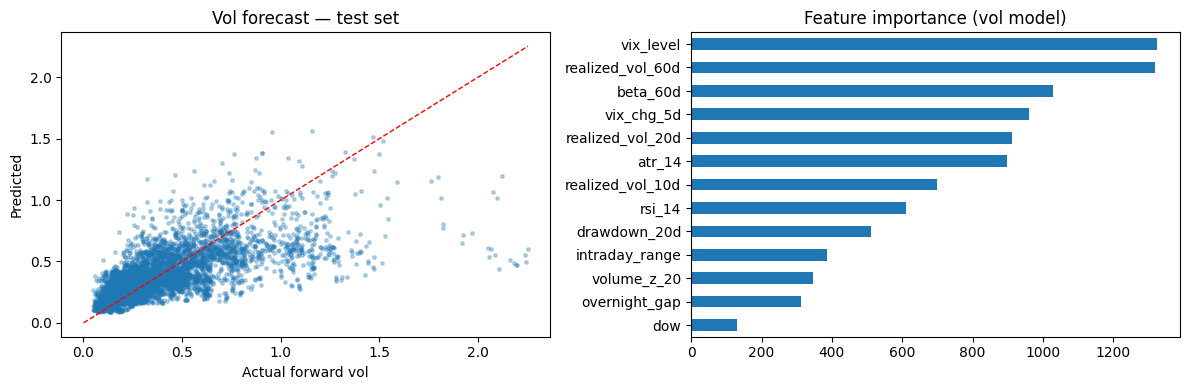

In [6]:
# ============================================================
# 5. MODEL 1 — VOLATILITY FORECASTER
# ============================================================
vol_model = lgb.LGBMRegressor(n_estimators=400, max_depth=5, learning_rate=0.03,
                               subsample=0.8, colsample_bytree=0.8, verbose=-1, random_state=42)
vol_model.fit(reg_train[FEATURE_COLS], reg_train["target_next_vol_10d"])

pred_val = vol_model.predict(reg_val[FEATURE_COLS])
pred_test = vol_model.predict(reg_test[FEATURE_COLS])

results["vol_forecaster"] = {}
for name, y_true, y_pred in [("val", reg_val["target_next_vol_10d"], pred_val),
                              ("test", reg_test["target_next_vol_10d"], pred_test)]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    results["vol_forecaster"][name] = {"mae": mae, "rmse": rmse, "r2": r2}
    print(f"[{name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(reg_test["target_next_vol_10d"], pred_test, s=6, alpha=0.3)
lims = [0, max(reg_test["target_next_vol_10d"].max(), pred_test.max())]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("Actual forward vol"); axes[0].set_ylabel("Predicted"); axes[0].set_title("Vol forecast — test set")

imp = pd.Series(vol_model.feature_importances_, index=FEATURE_COLS).sort_values()
imp.plot(kind="barh", ax=axes[1], title="Feature importance (vol model)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/vol_forecaster_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()


### 5b. Is the vol forecaster actually earning its keep?

Volatility is famously autocorrelated ("vol clustering") — a naive forecast that just says
*"tomorrow's vol = today's vol"* is a genuinely strong baseline, not a strawman. If the
trained model can't beat it, the model isn't adding value over what you'd get for free.


In [7]:
# ============================================================
# 5b. NAIVE BASELINE — persistence ("tomorrow's vol = today's vol")
# ============================================================
baseline_val_pred = reg_val["realized_vol_10d"]
baseline_test_pred = reg_test["realized_vol_10d"]

results["vol_forecaster_baseline"] = {}
for name, y_true, y_pred in [("val", reg_val["target_next_vol_10d"], baseline_val_pred),
                              ("test", reg_test["target_next_vol_10d"], baseline_test_pred)]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    results["vol_forecaster_baseline"][name] = {"mae": mae, "rmse": rmse, "r2": r2}
    model_mae = results["vol_forecaster"][name]["mae"]
    improvement_pct = (mae - model_mae) / mae * 100
    print(f"[{name}] naive persistence baseline: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.3f}"
          f"   |  model MAE is {improvement_pct:+.1f}% vs. baseline "
          f"({'model wins' if improvement_pct > 0 else 'baseline wins — model adds no skill here'})")


[val] naive persistence baseline: MAE=0.1432  RMSE=0.2406  R2=0.313   |  model MAE is +14.3% vs. baseline (model wins)
[test] naive persistence baseline: MAE=0.1639  RMSE=0.2565  R2=0.159   |  model MAE is +18.9% vs. baseline (model wins)


## 6. Leverage Formulation

Turn the volatility forecast into an actual **recommended max leverage number**, using a
standard inverse-volatility risk-budget rule: pick the leverage such that the *leveraged*
daily volatility hits your target daily VaR budget, then clip to sane bounds.

`recommend_leverage(vol) = clip(DAILY_VAR_BUDGET / vol, MIN_LEV, MAX_LEV)`

This is intentionally a transparent, auditable formula — not a black box — with the ML
model supplying the one genuinely hard-to-hand-code input (forward-looking volatility).
Tune `DAILY_VAR_BUDGET`, `MIN_LEV`, `MAX_LEV` to match Mochatrade's actual risk appetite.


In [8]:
# ============================================================
# 6. LEVERAGE FORMULATION
# ============================================================
DAILY_VAR_BUDGET = 0.02   # target 1-sigma daily loss budget on the leveraged position
MIN_LEV, MAX_LEV = 1.0, 10.0

def recommend_leverage(predicted_annual_vol, daily_budget=DAILY_VAR_BUDGET,
                        min_lev=MIN_LEV, max_lev=MAX_LEV):
    daily_vol = max(predicted_annual_vol, 1e-4) / np.sqrt(252)
    return float(np.clip(daily_budget / daily_vol, min_lev, max_lev))

demo_vols = np.linspace(0.10, 1.20, 12)
demo_table = pd.DataFrame({
    "predicted_annual_vol": demo_vols,
    "recommended_max_leverage": [recommend_leverage(v) for v in demo_vols],
})
demo_table.to_csv(f"{ARTIFACT_DIR}/leverage_formulation_table.csv", index=False)
results["leverage_formulation_params"] = {
    "daily_var_budget": DAILY_VAR_BUDGET, "min_lev": MIN_LEV, "max_lev": MAX_LEV,
}
print(demo_table.round(2).to_string(index=False))


 predicted_annual_vol  recommended_max_leverage
                  0.1                      3.17
                  0.2                      1.59
                  0.3                      1.06
                  0.4                      1.00
                  0.5                      1.00
                  0.6                      1.00
                  0.7                      1.00
                  0.8                      1.00
                  0.9                      1.00
                  1.0                      1.00
                  1.1                      1.00
                  1.2                      1.00


## 7. Model 2 — Margin-Breach / Leverage-Risk Classifier (calibrated)

This is the core "leverage detection" model: given today's market state **and a proposed
leverage**, what's the calibrated probability that tomorrow's move breaches the
maintenance-margin threshold? Because a risk product lives or dies on whether its
probabilities are *trustworthy* (not just well-ranked), we wrap the raw LightGBM model in
`CalibratedClassifierCV` and check a reliability diagram, not just AUC.


Test ROC-AUC: 0.8291   PR-AUC: 0.1424   Brier score: 0.05302

Confusion matrix @ threshold=0.5 (rows=actual, cols=predicted):
 [[41257    62]
 [ 1530    26]]


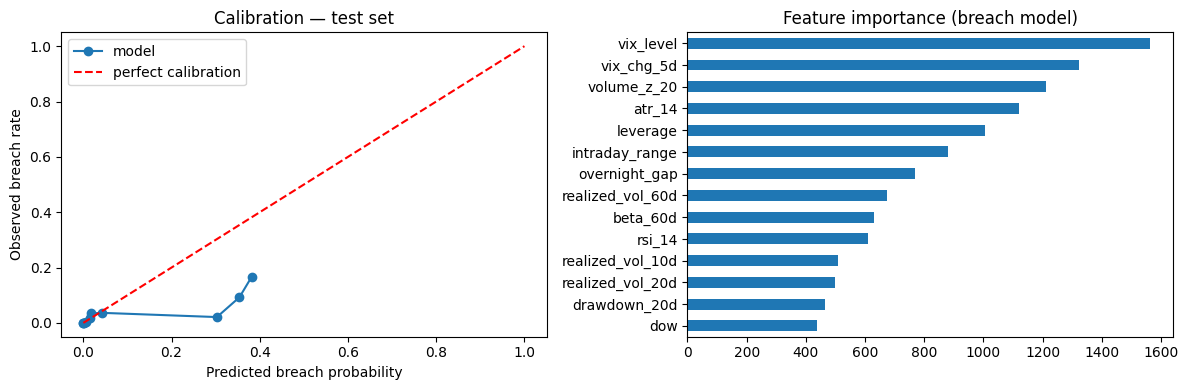

In [9]:
# ============================================================
# 7. MODEL 2 — MARGIN-BREACH CLASSIFIER (calibrated)
# ============================================================
CLF_FEATURES = FEATURE_COLS + ["leverage"]

base_clf = lgb.LGBMClassifier(n_estimators=400, max_depth=5, learning_rate=0.03,
                               subsample=0.8, colsample_bytree=0.8,
                               class_weight="balanced", verbose=-1, random_state=42)

# Fit once, unwrapped, purely so we can show real feature importances below.
base_clf.fit(clf_train[CLF_FEATURES], clf_train["breach_next_day"])

# CalibratedClassifierCV does its own internal cross-fitting (cv=3) on clf_train,
# so calibrated probabilities are never evaluated on data the base model saw fit on.
# (Deliberately avoiding the old cv="prefit" API — it was removed/changed across
# recent scikit-learn versions; internal cv is stable across versions.)
breach_model = CalibratedClassifierCV(
    lgb.LGBMClassifier(n_estimators=400, max_depth=5, learning_rate=0.03,
                        subsample=0.8, colsample_bytree=0.8,
                        class_weight="balanced", verbose=-1, random_state=42),
    method="isotonic", cv=3)
breach_model.fit(clf_train[CLF_FEATURES], clf_train["breach_next_day"])

proba_test = breach_model.predict_proba(clf_test[CLF_FEATURES])[:, 1]
y_test = clf_test["breach_next_day"]

auc = roc_auc_score(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)
brier = brier_score_loss(y_test, proba_test)
print(f"Test ROC-AUC: {auc:.4f}   PR-AUC: {ap:.4f}   Brier score: {brier:.5f}")

threshold = 0.5
preds = (proba_test >= threshold).astype(int)
cm = confusion_matrix(y_test, preds)
print("\nConfusion matrix @ threshold=0.5 (rows=actual, cols=predicted):\n", cm)

results["breach_classifier"] = {
    "test_roc_auc": auc, "test_pr_auc": ap, "test_brier": brier,
    "threshold": threshold, "confusion_matrix": cm.tolist(),
}

frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mean_pred, frac_pos, "o-", label="model")
axes[0].plot([0, 1], [0, 1], "r--", label="perfect calibration")
axes[0].set_xlabel("Predicted breach probability"); axes[0].set_ylabel("Observed breach rate")
axes[0].set_title("Calibration — test set"); axes[0].legend()

imp = pd.Series(base_clf.feature_importances_, index=CLF_FEATURES).sort_values()
imp.plot(kind="barh", ax=axes[1], title="Feature importance (breach model)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/breach_classifier_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()


### 7b. Picking a real decision threshold (0.5 is the wrong number here)

Breaches are rare (~3–4% base rate even at high leverage), so calibrated probabilities for
*genuinely risky* days still usually sit well below 0.5 — a 0.5 cutoff will barely flag
anything (in one real run this caught 8 of 1,563 actual breaches). That's not the model
failing; it's the threshold being wrong for a rare-event problem. We pick a threshold
properly instead: sweep precision/recall on the **validation set** (never on test — that
would be tuning on your own scoreboard), choose the threshold that hits a recall you
actually want, then report the confusion matrix at *that* threshold on test.


Chosen threshold (val, target recall=0.5): 0.3556  -> val precision=0.151, val recall=0.484

Confusion matrix @ chosen threshold (test, rows=actual, cols=predicted):
 [[37411  3908]
 [  844   712]]
Compare to @ threshold=0.5 (test):
 [[41257, 62], [1530, 26]]


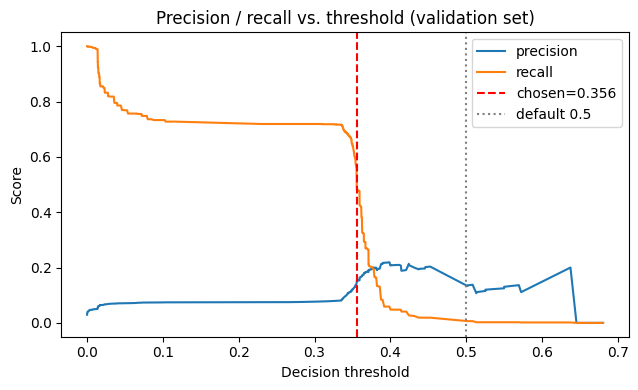

In [10]:
# ============================================================
# 7c. THRESHOLD SELECTION — via the precision/recall curve on VAL
# ============================================================
proba_val = breach_model.predict_proba(clf_val[CLF_FEATURES])[:, 1]
y_val = clf_val["breach_next_day"]

precisions, recalls, thresholds = precision_recall_curve(y_val, proba_val)

TARGET_RECALL = 0.5  # tune to your risk appetite: higher = catch more breaches, more false alarms
idx = np.argmin(np.abs(recalls[:-1] - TARGET_RECALL))
chosen_threshold = float(thresholds[idx])
print(f"Chosen threshold (val, target recall={TARGET_RECALL}): {chosen_threshold:.4f}  "
      f"-> val precision={precisions[idx]:.3f}, val recall={recalls[idx]:.3f}")

preds_chosen = (proba_test >= chosen_threshold).astype(int)
cm_chosen = confusion_matrix(y_test, preds_chosen)
print("\nConfusion matrix @ chosen threshold (test, rows=actual, cols=predicted):\n", cm_chosen)
print("Compare to @ threshold=0.5 (test):\n", results["breach_classifier"]["confusion_matrix"])

results["breach_classifier"]["chosen_threshold"] = chosen_threshold
results["breach_classifier"]["chosen_threshold_target_recall"] = TARGET_RECALL
results["breach_classifier"]["confusion_matrix_at_chosen_threshold"] = cm_chosen.tolist()

plt.figure(figsize=(6.5, 4))
plt.plot(thresholds, precisions[:-1], label="precision")
plt.plot(thresholds, recalls[:-1], label="recall")
plt.axvline(chosen_threshold, color="red", ls="--", label=f"chosen={chosen_threshold:.3f}")
plt.axvline(0.5, color="gray", ls=":", label="default 0.5")
plt.xlabel("Decision threshold"); plt.ylabel("Score"); plt.legend()
plt.title("Precision / recall vs. threshold (validation set)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/breach_threshold_selection.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Model 3 — Overnight Gap-Risk Forecaster

Predicts the magnitude of *tomorrow's* overnight gap. Overnight risk is where a leveraged
book gets hurt when it can't react intraday — this feeds overnight-margin sizing directly.


In [11]:
# ============================================================
# 8. MODEL 3 — OVERNIGHT GAP-RISK FORECASTER
# ============================================================
gap_model = lgb.LGBMRegressor(n_estimators=400, max_depth=5, learning_rate=0.03,
                               subsample=0.8, colsample_bytree=0.8, verbose=-1, random_state=42)
gap_model.fit(gap_train[FEATURE_COLS], gap_train["target_next_abs_gap"])

gap_pred_test = gap_model.predict(gap_test[FEATURE_COLS])
mae = mean_absolute_error(gap_test["target_next_abs_gap"], gap_pred_test)
rmse = mean_squared_error(gap_test["target_next_abs_gap"], gap_pred_test) ** 0.5
results["gap_forecaster"] = {"test_mae": mae, "test_rmse": rmse}
print(f"Overnight-gap forecaster — test MAE={mae:.5f}  RMSE={rmse:.5f}")
print("(units: log-return magnitude, e.g. 0.01 ≈ 1% overnight gap)")


Overnight-gap forecaster — test MAE=0.00752  RMSE=0.01436
(units: log-return magnitude, e.g. 0.01 ≈ 1% overnight gap)


### 8b. Is the gap forecaster actually earning its keep?

Same discipline as Section 5b: compare against the simplest possible naive baseline —
predicting tomorrow's overnight-gap magnitude as the **constant average** gap magnitude
seen in the training period. If the model can't beat "just guess the historical average,"
it isn't adding real skill.


In [12]:
# ============================================================
# 8c. NAIVE BASELINE — constant training-mean gap magnitude
# ============================================================
baseline_gap_value = float(gap_train["overnight_gap"].abs().mean())
results["gap_forecaster_baseline"] = {"constant_prediction": baseline_gap_value}

for name, df in [("val", gap_val), ("test", gap_test)]:
    y_true = df["target_next_abs_gap"]
    y_pred = np.full(len(df), baseline_gap_value)
    b_mae = mean_absolute_error(y_true, y_pred)
    b_rmse = mean_squared_error(y_true, y_pred) ** 0.5
    results["gap_forecaster_baseline"][name] = {"mae": b_mae, "rmse": b_rmse}
    print(f"[{name}] naive constant-mean baseline: MAE={b_mae:.5f}  RMSE={b_rmse:.5f}")

model_mae_test = results["gap_forecaster"]["test_mae"]
baseline_mae_test = results["gap_forecaster_baseline"]["test"]["mae"]
improvement_pct = (baseline_mae_test - model_mae_test) / baseline_mae_test * 100
print(f"\nModel {'improves' if improvement_pct > 0 else 'is worse than'} the naive baseline's "
      f"test MAE by {improvement_pct:+.1f}%")


[val] naive constant-mean baseline: MAE=0.00778  RMSE=0.01609
[test] naive constant-mean baseline: MAE=0.00845  RMSE=0.01569

Model improves the naive baseline's test MAE by +11.0%


## 9. Model 4 — Regime / Anomaly Detector

Unsupervised `IsolationForest` over volatility, liquidity, and gap features. Flags days
that look structurally unusual for a symbol — useful as an extra escalation signal
(e.g. "double-check this account's positions today, market state is anomalous") beyond
what any single supervised model directly targets.


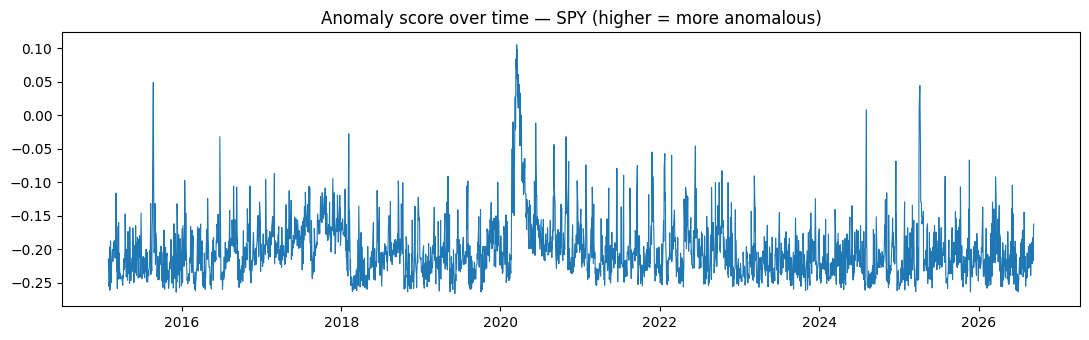

Most anomalous days for SPY :
                 close  realized_vol_10d  overnight_gap  anomaly_score
Date                                                                  
2020-03-16  218.627930          1.051062      -0.110356       0.104888
2020-03-18  218.764664          1.081644      -0.067708       0.097929
2020-03-12  226.157028          0.823960      -0.069264       0.083130
2020-03-13  245.490326          0.966271       0.058624       0.069979
2020-03-24  222.939194          1.130632       0.050167       0.060380


In [13]:
# ============================================================
# 9. MODEL 4 — ANOMALY / REGIME DETECTOR
# ============================================================
ANOMALY_FEATURES = ["realized_vol_10d", "volume_z_20", "intraday_range", "overnight_gap", "vix_level"]

anomaly_train_data = feat.dropna(subset=ANOMALY_FEATURES)
iso_model = IsolationForest(n_estimators=300, contamination=0.02, random_state=42)
iso_model.fit(anomaly_train_data[ANOMALY_FEATURES])

sample_symbol = TICKERS[0]
sym_feat = feat[feat["symbol"] == sample_symbol].dropna(subset=ANOMALY_FEATURES)
sym_feat = sym_feat.assign(anomaly_score=-iso_model.decision_function(sym_feat[ANOMALY_FEATURES]))

plt.figure(figsize=(11, 3.5))
plt.plot(sym_feat.index, sym_feat["anomaly_score"], lw=0.8)
plt.title(f"Anomaly score over time — {sample_symbol} (higher = more anomalous)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/anomaly_timeline_{sample_symbol}.png", dpi=120, bbox_inches="tight")
plt.show()

top_anomalies = sym_feat.sort_values("anomaly_score", ascending=False)[
    ["close", "realized_vol_10d", "overnight_gap", "anomaly_score"]].head(5)
top_anomalies.to_csv(f"{ARTIFACT_DIR}/top_anomalies_{sample_symbol}.csv")
print("Most anomalous days for", sample_symbol, ":")
print(top_anomalies)


## 10. Unified Inference Wrapper

A single object mirroring what the FastAPI `api/` service would actually call: give it a
symbol's current feature snapshot and a proposed leverage, get back every ML signal in one
dict. **Missing/insufficient features return `None` with a flag** — matching your "no
invented values" design — rather than a fabricated number.


In [14]:
# ============================================================
# 10. INFERENCE WRAPPER
# ============================================================
class MochaRiskML:
    def __init__(self, vol_model, breach_model, gap_model, iso_model,
                 feature_cols, clf_features, anomaly_features):
        self.vol_model = vol_model
        self.breach_model = breach_model
        self.gap_model = gap_model
        self.iso_model = iso_model
        self.feature_cols = feature_cols
        self.clf_features = clf_features
        self.anomaly_features = anomaly_features

    def assess(self, feature_snapshot: dict, proposed_leverage: float):
        """feature_snapshot: dict with (at least) all of self.feature_cols for one
        symbol as of one date. Returns None fields (with a flag) for anything that
        can't be computed from the given snapshot, rather than guessing."""
        missing = [c for c in self.feature_cols if c not in feature_snapshot or feature_snapshot[c] is None]
        if missing:
            return {"ok": False, "reason": f"missing required features: {missing}"}

        row = pd.DataFrame([feature_snapshot])

        predicted_vol = float(self.vol_model.predict(row[self.feature_cols])[0])
        recommended_leverage = recommend_leverage(predicted_vol)

        clf_row = row.copy()
        clf_row["leverage"] = proposed_leverage
        breach_proba = float(self.breach_model.predict_proba(clf_row[self.clf_features])[0, 1])

        predicted_gap = float(self.gap_model.predict(row[self.feature_cols])[0])

        anomaly_missing = [c for c in self.anomaly_features if c not in feature_snapshot]
        anomaly_score = None if anomaly_missing else float(
            -self.iso_model.decision_function(row[self.anomaly_features])[0])

        return {
            "ok": True,
            "predicted_forward_vol_10d": predicted_vol,
            "recommended_max_leverage": recommended_leverage,
            "proposed_leverage": proposed_leverage,
            "breach_probability_at_proposed_leverage": breach_proba,
            "predicted_next_overnight_gap_abs": predicted_gap,
            "anomaly_score": anomaly_score,
            "leverage_within_recommendation": proposed_leverage <= recommended_leverage,
        }

risk_ml = MochaRiskML(vol_model, breach_model, gap_model, iso_model,
                       FEATURE_COLS, CLF_FEATURES, ANOMALY_FEATURES)

# demo using the most recent real row for one symbol
demo_row = feat[feat["symbol"] == TICKERS[0]].dropna(subset=FEATURE_COLS).iloc[-1]
demo_snapshot = demo_row[FEATURE_COLS].to_dict()
result = risk_ml.assess(demo_snapshot, proposed_leverage=4.0)
results["inference_demo"] = result
result


{'ok': True,
 'predicted_forward_vol_10d': 0.09710206912597984,
 'recommended_max_leverage': 3.2696538826154202,
 'proposed_leverage': 4.0,
 'breach_probability_at_proposed_leverage': 0.0074552683896620285,
 'predicted_next_overnight_gap_abs': 0.004566003940370461,
 'anomaly_score': -0.16248793582294802,
 'leverage_within_recommendation': False}

## 11. Save & Export — persist everything to Google Drive

This is the run's permanent record: the 4 trained models, every metric computed above,
every diagnostic plot, the leverage-formulation table, and the top-anomalies table — all
written to `/content/artifacts` as we went, and copied here into your Google Drive under
**`MyDrive/MochaGuard/risk_ml_runs/`**:

- `risk_ml_runs/<UTC timestamp>/` — an immutable snapshot of this exact run (never overwritten)
- `risk_ml_runs/latest/` — always the most recent run; point `api/` or any downstream job here

Running this cell will pop up a Google sign-in / Drive-access prompt the first time —
approve it. If you're not running in an actual Colab session, it automatically falls back
to a local zip instead of failing.


In [15]:
# ============================================================
# 11. SAVE & EXPORT — persist to Google Drive
# ============================================================
joblib.dump(vol_model, f"{MODELS_DIR}/vol_forecaster.joblib")
joblib.dump(breach_model, f"{MODELS_DIR}/breach_classifier.joblib")
joblib.dump(gap_model, f"{MODELS_DIR}/gap_forecaster.joblib")
joblib.dump(iso_model, f"{MODELS_DIR}/anomaly_detector.joblib")

metadata = {
    "trained_at_utc": datetime.utcnow().isoformat(),
    "tickers": TICKERS,
    "date_range": [START, END],
    "feature_cols": FEATURE_COLS,
    "clf_features": CLF_FEATURES,
    "anomaly_features": ANOMALY_FEATURES,
    "leverage_tiers": LEVERAGE_TIERS,
    "maintenance_threshold": MAINTENANCE_THRESHOLD,
    "daily_var_budget": DAILY_VAR_BUDGET,
    "notes": "breach labels are derived from real price data via MAINTENANCE_THRESHOLD, "
             "not observed real margin calls — recalibrate against Mochatrade's actual "
             "margin schedule before production use.",
}
with open(f"{ARTIFACT_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
with open(f"{ARTIFACT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)

print("Local artifacts staged in", ARTIFACT_DIR, ":")
for root, _, fnames in os.walk(ARTIFACT_DIR):
    for fn in fnames:
        print(" -", os.path.join(root, fn))

# ---- copy everything to Google Drive (primary destination) ----
try:
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_ROOT = "/content/drive/MyDrive/MochaGuard/risk_ml_runs"
    RUN_ID = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
    DRIVE_RUN_DIR = f"{DRIVE_ROOT}/{RUN_ID}"   # permanent, timestamped snapshot of this run
    DRIVE_LATEST_DIR = f"{DRIVE_ROOT}/latest"  # always overwritten — point api/ at this one

    shutil.copytree(ARTIFACT_DIR, DRIVE_RUN_DIR)
    if os.path.exists(DRIVE_LATEST_DIR):
        shutil.rmtree(DRIVE_LATEST_DIR)
    shutil.copytree(ARTIFACT_DIR, DRIVE_LATEST_DIR)

    print(f"\nSaved to Google Drive:")
    print(f"  Versioned run : {DRIVE_RUN_DIR}")
    print(f"  Latest        : {DRIVE_LATEST_DIR}")
except ImportError:
    zip_path = "/content/mochatrade_risk_ml.zip"
    shutil.make_archive(zip_path.replace(".zip", ""), "zip", ARTIFACT_DIR)
    print(f"\nNot running in Colab — Drive skipped. Local zip saved instead: {zip_path}")


Local artifacts staged in /content/artifacts :
 - /content/artifacts/metadata.json
 - /content/artifacts/leverage_formulation_table.csv
 - /content/artifacts/top_anomalies_SPY.csv
 - /content/artifacts/results.json
 - /content/artifacts/models/breach_classifier.joblib
 - /content/artifacts/models/anomaly_detector.joblib
 - /content/artifacts/models/gap_forecaster.joblib
 - /content/artifacts/models/vol_forecaster.joblib
 - /content/artifacts/plots/breach_threshold_selection.png
 - /content/artifacts/plots/anomaly_timeline_SPY.png
 - /content/artifacts/plots/vol_forecaster_diagnostics.png
 - /content/artifacts/plots/breach_classifier_diagnostics.png
Mounted at /content/drive

Saved to Google Drive:
  Versioned run : /content/drive/MyDrive/MochaGuard/risk_ml_runs/20260912_025434
  Latest        : /content/drive/MyDrive/MochaGuard/risk_ml_runs/latest


## 12. Plugging this into `api/`

1. In Drive, open `MyDrive/MochaGuard/risk_ml_runs/latest/` — that's `models/` (4 `.joblib`
   files), `plots/` (diagnostics), `metadata.json`, `results.json`, and the two CSVs.
2. Download or `rclone`/API-sync that `latest/` folder into e.g. `api/app/ml/`.
3. Add a small `risk_ml.py` that loads the four `joblib` files once at startup and exposes
   `MochaRiskML.assess(...)` (paste the class from Section 10).
4. In your existing decision pipeline, compute the real feature snapshot for the symbol
   (same formulas as Section 2, using your already-persisted Alpha Vantage / yfinance
   history) and call `risk_ml.assess(snapshot, proposed_leverage)`.
5. Surface `recommended_max_leverage` and `breach_probability_at_proposed_leverage`
   **alongside** your existing deterministic leverage/margin decision — as an extra
   explanation input for the downstream Groq step, or as a second opinion that can
   escalate a decision, not silently override it.
6. Retrain on a schedule (e.g. weekly) as new market data lands — re-running this notebook
   end to end drops a fresh timestamped folder in Drive automatically and refreshes
   `latest/`, so you always have a rollback point. Track live Brier score / calibration on
   real outcomes and re-run Section 7's calibration check periodically.

**Next upgrades, if you want to keep going:** replace the maintenance-margin proxy with
real historical breach/liquidation events once you have them; add options-implied vol
(if Mochatrade ever adds derivatives) as a feature; add per-account behavioral features
(position concentration, days since last rebalance) for a genuinely personalized risk
score instead of a purely market-state-based one.
